**Proyecto: Clasificador Inteligente de Imágenes de Ropa**


**Evaluación del módulo 8: FUNDAMENTOS DE DEEP LEARNING**

In [286]:
import os

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

os.makedirs("images", exist_ok=True)

**Lección 1: LA RED NEURONAL ARTIFICIAL**

Objetivo: Comprender los elementos de una red neuronal artificial y
su rol en la resolución de problemas.

Una red neuronal artificial es un modelo de aprendizaje automático inspirado en el funcionamiento del cerebro humano, compuesto por neuronas organizadas en capas (entrada, ocultas y salida). Cada neurona recibe entradas, las pondera mediante pesos, suma un sesgo y aplica una función de activación para generar una salida.

A continuación se implementa una red neuronal densa (fully conected), donde cada neurona de una capa está conectada con todas las de la siguiente. 

La arquitectura utilizada incluye capas ocultas con función de activación ReLU, que introduce no linealidad y permite aprender patrones complejos, y una capa de salida con sigmoid para clasificación binaria, ya que su salida puede interpretarse como probabilidad.

El modelo se entrena ajustando sus pesos mediante un proceso de optimización (como Adam), minimizando una función de pérdida. En este caso, se utiliza binary crossentropy, adecuada para problemas de clasificación binaria, ya que mide la diferencia entre las probabilidades predichas y las etiquetas reales.

In [260]:
basemodel = Sequential([
    Dense(128, activation='relu', input_shape=(20,)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

basemodel.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

basemodel.summary()

/Users/cosmotropia/dataScience course/ABP8-KNN/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_101 (Dense)               │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)

Función para la carga de imagenes, esta lee el archivo binario, indicandole con dtype=np.uint8 que cada píxel está guardado como entero sin signo de 8 bits, o sea valores entre 0 y 255 y un offset=16 que salta los primeros 16 bytes del archivo, ya que corresponden al encabezado metadata del archivo IDX de imágenes. Con reshape se reorganiza el vector plano en una coleccion de imagenes de 28x28, ya que cada imagen de Fashion-MNIST mide 28x28 y con -1 le decimos a NumPy que calcule automaticamente cuantas imagenes hay

In [261]:
def load_images(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
    return data.reshape(-1, 28, 28)
    

Función para cargar etiquetas. Las etiquetas usan un encabezado distinto de 8 bytes por lo cual se indica como offset

In [262]:
def load_labels(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return data

Cargamos el dataset con datos de entrenamiento y de prueba

In [263]:
X_train = load_images("data/train-images-idx3-ubyte")
y_train = load_labels("data/train-labels-idx1-ubyte")
X_test = load_images("data/t10k-images-idx3-ubyte")
y_test = load_labels("data/t10k-labels-idx1-ubyte")


El dataset Fashion-MNIST fue cargado correctamente desde archivos binarios en formato IDX. El conjunto de entrenamiento contiene 60.000 imágenes de tamaño 28x28 píxeles, mientras que el conjunto de prueba incluye 10.000 imágenes con las mismas características. Cada imagen está asociada a una etiqueta numérica que representa su categoría. Esta estructura permite abordar el problema como una tarea de clasificación multiclase

In [264]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


Continuamos con la normalización
Las imágenes serán normalizadas al rango [0,1] dividiendo los valores de píxeles por 255, lo que mejora la estabilidad del entrenamiento. Posteriormente, las imágenes serán aplanadas a vectores de 784 características para poder ser utilizadas en una red neuronal densa, la cual requiere entradas en formato vectorial.

In [265]:
# Normalizacion
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Aplanamiento (conversion a vector)
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

# Verificar
print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


Ahora creamos el modelo.
La primera capa recibe la imagen 784 pixeles y aprende primeras comboinaciones de features. Utilizamos 128 neuronas en esta primera prueba, considerando que ocn eas cantidad es suficiente sin ser pesado, utilizamos como estandar ne problemas basicos.
Con dropout 0.3 apagamos aleatoriamente el 30% de neuronas con el finde evitar ovefitting y mejorar generalizacion
Utilizamos relu porque introduce no linealidad y evita que el modelo sea solo una regresion lineal. En esta capa se refinan los patrones aprendidos y se reduce dimensionalidad de 128 a 64, mientras mas profundo mas capacidad de abstraccion

Luego la capa de salida que genera 10 probabilidades, una por clase

In [266]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

A continuación, compilamos el modelo usando adam como optimizador, el cual ajusta los pesos automaticamente, es rapido y eficiente, se consider aun estandar en deep learning. Como funcion de perdida utilizamos crossentropy ya que tenemos multiples clases y las etiquetas son numeros del 0 al 9 , por eso se utilzia sparse 

In [267]:
#Compilamos el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [268]:
model.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_104 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_106 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Lección 2: DEEP LEARNING**

Objetivo: Reconocer las principales arquitecturas, usos y frameworks de Deep Learning.

**Arquitectura óptima para la clasificación de imágenes**

Para las tareas de clasificacion de imagenes, la arquitectura mas acdecuada corresponde a las redes neuronales convolutivas (CNN). A diferencia de las redes densas, las CNN estan diseñadas apra trabajkar directamente con datos en formato imagen, aprovechando su estructura espacial. Etsas redes, utilizan capas convoluticas que aplican filtkros sobre la imagen para detectar patrones locales como bordes, texturas y formas, permitiendo construir represetnaciones jerárquizas cada vez mas complejhas
Además, incorporan capas de pooling que reducen la dimensionalidad, manteniendo la información relevante y disminuyendo el costo computacional. Esta combinación permite que las CNN sean altamente efectivas en problemas de visión computacional, como la clasificación de imágenes

**Red densas vs convolutivas**
​​Las redes neuronales densas (fully connected) procesan los datos como vectores planos, lo que implica perder la estructura espacial de las imágenes. Esto limita su capacidad para identificar patrones visuales relevantes.
En contraste, las redes convolutivas (CNN) mantienen la estructura bidimensional de las imágenes y utilizan filtros para detectar características locales, lo que las hace más eficientes y precisas en tareas de clasificación de imágenes.

**Selección de framework**
Para la implementación del modelo se seleccionó Keras (TensorFlow) como framework principal. Esta elección se debe a su alto nivel de abstracción, facilidad de uso y rapidez en la construcción de modelos. Keras permite definir arquitecturas de redes neuronales de manera clara y concisa,lo que facilita la experimentación con diferentes configuraciones.
PyTorch, ofrece mayor flexibilidad y control a nivel bajo, especialmente en entornos de investigación, sin embargo, Keras resulta más adecuado para este proyecto, ya que permite enfocarse en el diseño y evaluación del modelo sin complejidad adicional en la implementación


**Lección 3: IMPLEMENTACIÓN DE RN EN PYTHON**

Objetivo: Diseñar y entrenar una red neuronal con Python para resolver un problema de clasificación.

Pa llevar a cabo el desarrollo de esta lección, se entrena una red neuronal densa durante 10 épocas, es decir, recorre todo el dataset de entrenamiento 10 veces. Esto permite ajustar los pesos de forma progresiva. Se utiliza un batch size de 32 y un 20% de los datos para validación.

El modelo alcanza aproximadamente un 87% de precisión, lo que es consistente con un modelo base denso para este dataset

In [269]:
history = model.fit(
    X_train_flat,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7893 - loss: 0.5898 - val_accuracy: 0.8388 - val_loss: 0.4352
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8408 - loss: 0.4376 - val_accuracy: 0.8507 - val_loss: 0.4104
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8518 - loss: 0.4027 - val_accuracy: 0.8725 - val_loss: 0.3543
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8617 - loss: 0.3786 - val_accuracy: 0.8687 - val_loss: 0.3664
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8674 - loss: 0.3608 - val_accuracy: 0.8652 - val_loss: 0.3610
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8687 - loss: 0.3524 - val_accuracy: 0.8791 - val_loss: 0.3381
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8724 - loss: 0.3436 - val_accuracy: 0.8711 - val_loss: 0.3555
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8777 - loss: 0.3290 - 

In [270]:
test_loss, test_acc = model.evaluate(X_test_flat, y_test)

print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.8793 - loss: 0.3442
Test accuracy: 0.8792999982833862


Las curvas muestran un aprendizaje progresivo. Se observa un leve sobreajuste en las últimas épocas. El modelo presenta un comportamiento estable, donde tanto la precisión de entrenamiento como la de validación aumentan de forma consistente. No se observa una diferencia significativa entre ambas curvas, lo que indica un buen equilibrio entre aprendizaje y generalización.

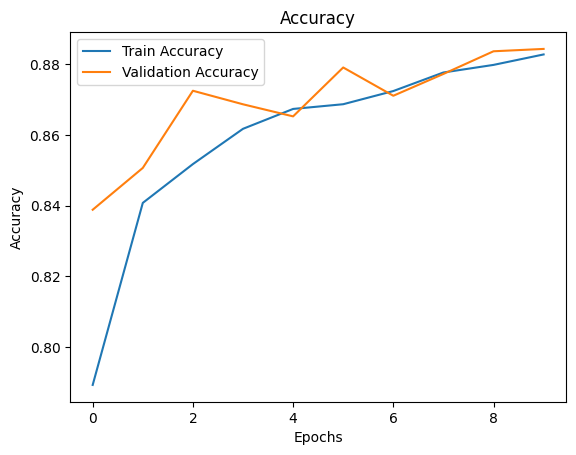

In [271]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('images/accuracy.png')
plt.show()

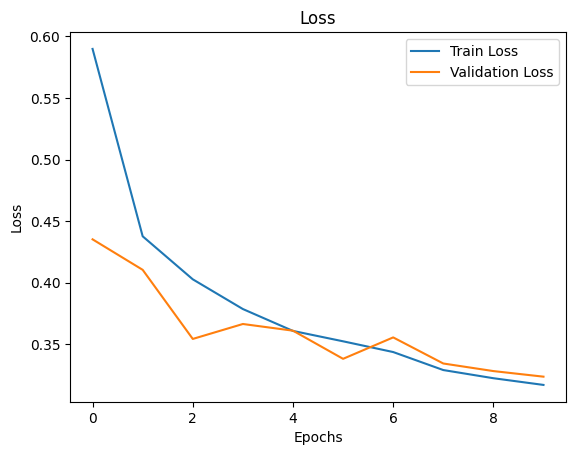

In [272]:
# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('images/loss.png')
plt.show()

Se realizó un segundo experimento aumentando el número de épocas de entrenamiento a 15. El modelo alcanzó una precisión de aproximadamente 87.3% en el conjunto de prueba, mostrando una mejora marginal respecto al modelo base. Sin embargo, el análisis de las curvas de entrenamiento y validación evidencia un leve sobreajuste, ya que la precisión en entrenamiento continúa aumentando mientras que la de validación se mantiene estable.

Esto indica que incrementar el número de épocas no genera una mejora significativa en la capacidad de generalización del modelo, y puede conducir a un ajuste excesivo a los datos de entrenamiento

In [273]:
model_2 = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

#Compilamos el modelo
model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    X_train_flat,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7937 - loss: 0.5799 - val_accuracy: 0.8478 - val_loss: 0.4169
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8417 - loss: 0.4347 - val_accuracy: 0.8599 - val_loss: 0.3855
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8532 - loss: 0.4005 - val_accuracy: 0.8638 - val_loss: 0.3699
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8589 - loss: 0.3830 - val_accuracy: 0.8720 - val_loss: 0.3528
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8651 - loss: 0.3649 - val_accuracy: 0.8773 - val_loss: 0.3415
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8689 - loss: 0.3529 - val_accuracy: 0.8714 - val_loss: 0.3567
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8742 - loss: 0.3414 - val_accuracy: 0.8807 - val_loss: 0.3370
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8764 - loss: 0.3335 - 

In [274]:
test_loss_2, test_acc_2 = model_2.evaluate(X_test_flat, y_test)

print("Test accuracy:", test_acc_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8807 - loss: 0.3386
Test accuracy: 0.8806999921798706


El análisis muestra que la precisión del modelo aumenta de forma progresiva a lo largo de las épocas, alcanzando valores cercanos al 90% en el conjunto de entrenamiento. Sin embargo, la precisión en validación se estabiliza alrededor del 88% y presenta ligeras fluctuaciones, sin una mejora sostenida

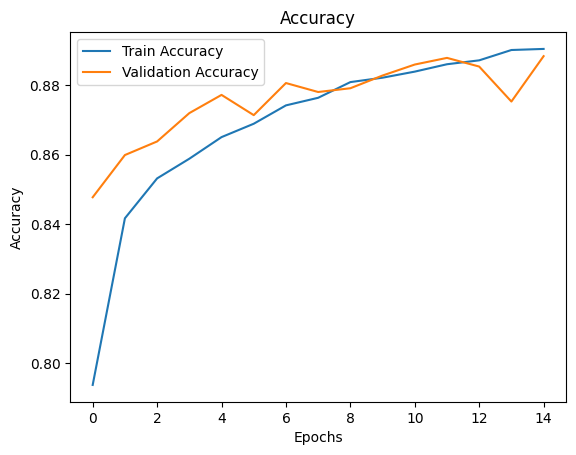

In [275]:
# Accuracy
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('images/accuracy_2.png')
plt.show()

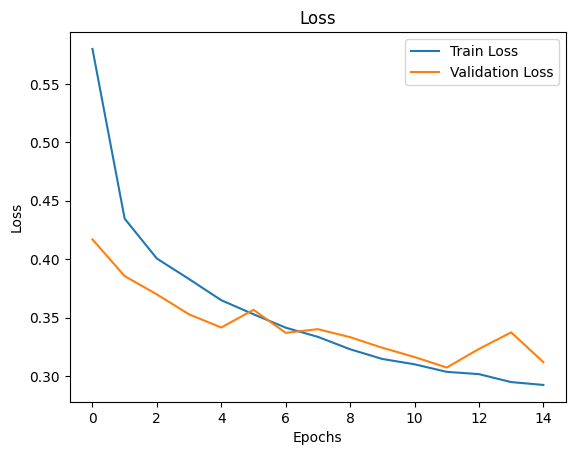

In [276]:
# Loss
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('images/loss_2.png')
plt.show()

La comparación entre modelos muestra que, aunque el modelo con 15 épocas alcanza una ligera mejora en precisión, presenta mayor variabilidad en la validación, lo que sugiere menor estabilidad. En contraste, el modelo con 10 épocas muestra un comportamiento más consistente, siendo una mejor elección en términos de generalización

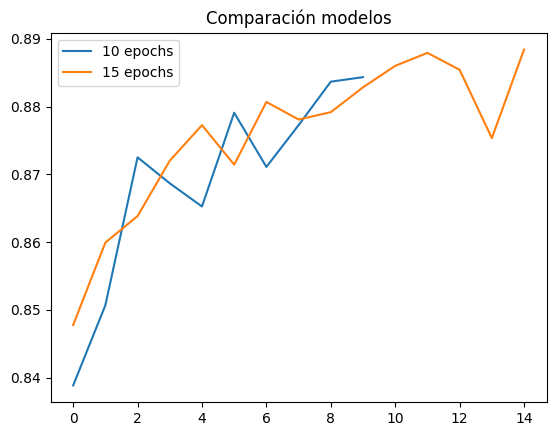

In [277]:
plt.plot(history.history['val_accuracy'], label='10 epochs')
plt.plot(history_2.history['val_accuracy'], label='15 epochs')

plt.legend()
plt.title("Comparación modelos")
plt.savefig('images/comparacion_modelos.png')
plt.show()

se concluye que aumentar el número de épocas permite mejorar el desempeño del modelo hasta cierto punto. Sin embargo, un exceso de entrenamiento conduce al sobreajuste, afectando la capacidad de generalización. En este caso, el modelo con 10 épocas presenta un mejor equilibrio entre precisión y estabilidad, siendo preferible frente a configuraciones con mayor número de iteraciones

**Lección 4: REDES NEURONALES CONVOLUTIVAS**

Dado que las redes densas no aprovechan la estructura espacial de las imágenes, se procede a implementar una red neuronal convolutiva (CNN), la cual permite capturar patrones locales como bordes y formas, mejorando el rendimiento del modelo

**Reestructuración de datos**

Se ajusta la forma de los datos para CNN, agregando el canal (escala de grises)

In [278]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

Se implementa una CNN con capas convolutivas, pooling, y capas densas finales

La arquitectura CNN incluye:

- Capas Conv2D para detectar patrones espaciales

- MaxPooling para reducir dimensionalidad

- Flatten para convertir la salida en vector

- Capas densas para clasificación final

- Dropout como regularización

In [279]:
model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

/Users/cosmotropia/dataScience course/ABP8-KNN/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Se utiliza el optimizador Adam y la función de pérdida adecuada para clasificación multiclase

In [280]:
model_cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Se entrena la CNN utilizando validación para monitorear el desempeño.

Se puede observar que la red convolutiva alcanza una precisión superior al modelo denso, evidenciando su capacidad para capturar patrones espaciales en las imágenes. Esto confirma que las CNN son más adecuadas para tareas de clasificación de imágenes

In [281]:
model_cnn.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7851 - loss: 0.5944 - val_accuracy: 0.8614 - val_loss: 0.3784
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8567 - loss: 0.3988 - val_accuracy: 0.8832 - val_loss: 0.3222
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8745 - loss: 0.3474 - val_accuracy: 0.8910 - val_loss: 0.2979
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8882 - loss: 0.3143 - val_accuracy: 0.8931 - val_loss: 0.2864
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8954 - loss: 0.2858 - val_accuracy: 0.9013 - val_loss: 0.2723
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8997 - loss: 0.2702 - val_accuracy: 0.9062 - val_loss: 0.2573
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9068 - loss: 0.2531 - val_accuracy: 0.9062 - val_loss: 0.2628
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9123 - loss: 0.

In [282]:
model_cnn.save("fashion_model.h5")

Se realizaron predicciones sobre imágenes individuales, verificando que el modelo es capaz de identificar correctamente las categorías visuales

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


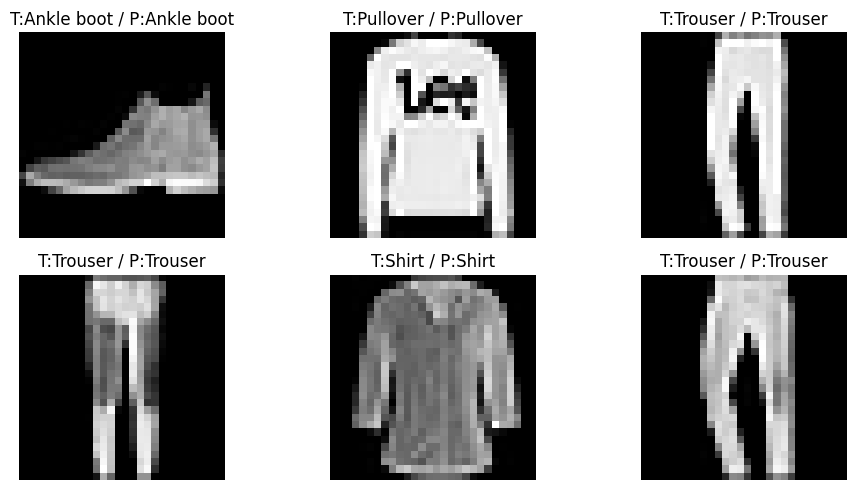

In [285]:
plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    
    img = X_test[i]
    true_label = y_test[i]
    
    pred = model_cnn.predict(X_test[i:i+1])
    pred_class = np.argmax(pred)
    
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{classes[true_label]} / P:{classes[pred_class]}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("images/pred_multiple.png")
plt.show()

**Conclusión**

Se implementaron dos enfoques: una red neuronal densa y una red convolutiva. Mientras que el modelo denso logró un desempeño adecuado, la CNN mostró una mejora significativa en precisión, demostrando su capacidad para capturar patrones espaciales en imágenes, confirmando que las arquitecturas convolutivas son más apropiadas para problemas de clasificación de imágenes.

Con respecto a los resultados, se visualizan predicciones del modelo sobre imágenes del conjunto de prueba, comparando la etiqueta real con la predicha. Los resultados muestran que el modelo es capaz de identificar correctamente la mayoría de las clases, lo que valida su desempeño en tareas de clasificación de imágenes.